In [32]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
# import operator
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
load_dotenv()

from langgraph.checkpoint.memory import MemorySaver


In [33]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [34]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [35]:
def chat_node(state: ChatState):
    #take user query from state to LLm and store the response
    messages = state['messages']
    
    response= llm.invoke(messages)
    
    return {'messages':[response]}

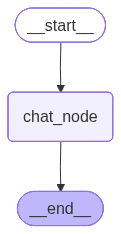

In [36]:
checkpointer = MemorySaver()

graph= StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
    
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot= graph.compile(checkpointer= checkpointer)
chatbot

In [37]:
initial_state={
    'messages':[HumanMessage(content='Name 5 cities of MP')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id='1'

while True:
    user_message=input('type here')
    print(f'User: {user_message}')
    
    if user_message.strip().lower() in ['exit','quit','bye','thank you']:
        break
    config={'configurable':{'thread_id': thread_id}}
    response= chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    
    print('AI:',response['messages'][-1].content)

User: hello i am Yash
AI: Hello Yash, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: what is my name
AI: Your name is Yash. You told me that when you first said hello.
User: okay thank you 
AI: You're welcome, Yash. If you need anything else, feel free to ask. Have a great day!
User: thank you 


In [39]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello i am Yash', additional_kwargs={}, response_metadata={}, id='1b1b459d-6fc7-4578-a8c4-3db14d056692'), AIMessage(content="Hello Yash, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 40, 'total_tokens': 67, 'completion_time': 0.044534672, 'completion_tokens_details': None, 'prompt_time': 0.003228857, 'prompt_tokens_details': None, 'queue_time': 0.010365852, 'total_time': 0.047763529}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_4f6d808339', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dee75-2d3f-7540-b321-fd428ad1908f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 27, 'total_tokens': 67}), HumanMessage(content='what is my name', additional_kwargs={}, 

##Persistent
